# Training the stream-cleaning/detection U-Net, step by step

This notebook builds on `create_data.ipynb`: it reuses the same background +
matched-filter + `StreamInjector` construction, then wires up the rest of the
pipeline -- `StreamMapDataset`, `StreamMapTransform`/`RobustNormalizer`,
`models.unet.UNet`, `models.losses`, `training.plain_runner.PlainTrainer`, and
`evaluation/` -- and runs one short **real** training loop end to end.

`label_policy="stream_detection"` (PLAN.md §6.12): the network is trained to
output, per pixel, a probability that a real stream detection sits there
(`stream_raw > count_threshold`), not a literal star count. An earlier
version of this notebook trained `label_policy="stream_count"` (literal
counts) directly -- it localized streams well but persistently
under-recovered their peak amplitude by a large factor (see
{doc}`../narrative/ml_concepts` for why); retargeting at the bounded
detection label sidesteps that problem entirely rather than fighting it.

This is a smoke-scale run (few epochs, few steps per epoch) -- it proves the
whole pipeline trains and evaluates for real, not a scientifically tuned
model. Scaling up (more steps/epochs, a richer eval grid, GPU, the
`training/hyrax_runner.py` orchestration layer) is future work.

In [1]:
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

from streamgoggles.background import Background
from streamgoggles.background_sources import StreamObsLightBackgroundSource, StudyRegion
from streamgoggles.config import DistributionType, ParameterSpec, StreamConfig
from streamgoggles.data_preparation import Cut
from streamgoggles.datasets.stream_map_dataset import StreamMapDataset, stream_map_collate_fn
from streamgoggles.datasets.transforms import RobustNormalizer, StreamMapTransform
from streamgoggles.evaluation.baseline_threshold import build_baseline
from streamgoggles.evaluation.completeness_purity import evaluate_on_grid, plot_recovery_vs_parameter
from streamgoggles.evaluation.metrics import dice, iou
from streamgoggles.injector import StreamInjector
from streamgoggles.matched_filter import PixelizationSpec, ShiftedColorBoxFilter, StreamobsSplineFilter
from streamgoggles.models.losses import get_loss
from streamgoggles.models.unet import UNet
from streamgoggles.storage import BackgroundMapStore, ModelStore, SimulationStore
from streamgoggles.stream_sources import StreamObsSource
from streamgoggles.training.plain_runner import PlainTrainer

%matplotlib inline


## 1. Configuration

Background/matched-filter/window config mirrors `create_data.ipynb`, with
`nside=512` (the standard resolution for stream search, PLAN.md §6.12) and
`pixel_scale_deg` never set by hand (auto-derived from `nside` alone).
`image_size_pix` (a separate, independent choice from `nside`) is kept
modest for training-loop speed -- per-sample generation cost is dominated
by the background catalog's own selection/injection cost, not by window
pixel count (verified for real: ~1s/sample regardless of `image_size_pix`
at fixed catalog size), so this choice is really about keeping the model's
own compute small, not about generation speed.

`count_threshold=1.0` (`StreamInjector`'s own default, PLAN.md §6.13) --
not the `count_threshold=10.0` an earlier version of this notebook used.
That value made `label_policy="stream_detection"`'s label entirely empty
for `surface_brightness` fainter than ~31 at this `nside`/geometry, which
directly conflicts with this project's real observational range (streams
already detected down to SB 33, with an ambition to reach 34-35).
`count_threshold=1.0` is the lowest threshold that keeps a non-empty label
all the way to SB 35, at a real, deliberately-accepted cost: the "decoy"
filter's own positive-pixel count becomes a substantial fraction of
"good"'s at the *bright* end (SB 30-31) -- see `create_data.ipynb`'s
"Calibrating count_threshold empirically" section (§4) for the full
sweep and reasoning, and PLAN.md §6.13 for the decision log.

`stream_param_cfg["richness"] = [31.0, 32.0, 33.0, 34.0]` (surface_brightness,
DISCRETE -- an eval grid point per value, PLAN.md §6.13): with
`count_threshold=1.0`, every point in this range produces a genuinely
non-empty label at this project's own `cuts_cfg`/`clipping_cfg` (verified
for real): good-channel positive-pixel counts of roughly 565, 312, 193, 27
respectively, with decoy contamination low across the whole range (33% at
SB 31, dropping to ~1% by SB 33, 0% at SB 34) -- unlike the bright end (SB
30, not included here), which is both the easiest case for the network
*and* where decoy contamination is worst, so it's dropped from this scan
in favor of the range where the network's discrimination actually has
something to prove. Whether SB 34 -- the faintest, thinnest-labeled point
-- is recovered well by the network, or needs more training budget/a
different threshold, is exactly what §7's per-richness Dice curve below is
for.

In [2]:
SEED = 42

study_region_cfg = dict(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

cuts_cfg = [
    dict(quantity="mag", band="g", op="<", value=26.5),
    dict(quantity="mag", band="r", op="<", value=26.0),
]
clipping_cfg = {"g": {"min": 16.0, "max": 25.}, "r": {"min": 16.0, "max": 25.0}}

background_cfg = dict(
    source="light",
    survey="lsst",
    release="yr1",
    source_kwargs={},
    finalize={"enabled": False},
)

filters_cfg = dict(
    good=dict(type="isochrone", reference_isochrone=dict(age=12.5, z=0.0002)),
    decoy=dict(type="shifted_box", reference="good", color_shift=0.5, color_width=0.3),
)

# nside=512, pixel_scale_deg auto-derived (never set by hand) -- see §1.
matched_filter_cfg = dict(
    bands=["g", "r"],
    pixelization=dict(nside=512, image_size_pix=(96, 96)),
    distance_moduli=[16.0,],
)

window_cfg = dict(min_stream_length_deg=5.0, max_attempts=100)

# count_threshold: label_policy="stream_detection"'s per-pixel star-count
# cut (§2) -- a pixel is a "detection" once its true stream-only count
# exceeds this. 1.0 is StreamInjector's own default, calibrated
# empirically (PLAN.md §6.13) -- see §1 markdown above.
count_threshold = 1.0

stream_param_cfg = dict(
    morphology="uniform",
    richness=[31.0, 32.0, 33.0, 34.0],  # DISCRETE surface_brightness (mag/arcsec^2) -- see §1
    width=0.2,
    length=8.0,
    distance_modulus=16.,  # matches a trial distance in matched_filter_cfg
    age=12.5,
    z=0.0002,
)

model_cfg = dict(base_width=12, depth=2, head="sigmoid")

train_cfg = dict(
    epochs=15,
    steps_per_epoch=20,
    batch_size=2,
    lr=2e-3,
    background_fraction=0.05,
    loss_name="dice",
)

namespace = f"{background_cfg['survey']}_{background_cfg['release']}"

## 2. Build background + matched filters + injector

Exactly `create_data.ipynb` §2.2-2.3 and §3 -- see that notebook for the
step-by-step breakdown of what `StreamInjector.inject_single_stream` does
internally.


In [3]:
study_region = StudyRegion(**study_region_cfg)
pix = PixelizationSpec(**matched_filter_cfg["pixelization"])

matched_filters = {}
for name, cfg in filters_cfg.items():
    if cfg["type"] == "isochrone":
        matched_filters[name] = StreamobsSplineFilter(
            iso_config=cfg["reference_isochrone"], namespace=namespace
        )
    elif cfg["type"] == "shifted_box":
        matched_filters[name] = ShiftedColorBoxFilter(
            reference_filter=matched_filters[cfg["reference"]],
            color_shift=cfg["color_shift"],
            color_width=cfg["color_width"],
        )
    else:
        raise ValueError(f"unknown filter type {cfg['type']!r}")

cuts = [Cut(**c) for c in cuts_cfg]
bg_store = BackgroundMapStore(tempfile.mkdtemp(prefix="streamgoggles_train_bgmaps_"))

background = Background.load_or_cache(
    source=StreamObsLightBackgroundSource(),
    source_cfg=background_cfg["source_kwargs"],
    study_region=study_region,
    cuts=cuts,
    clipping=clipping_cfg,
    matched_filters=matched_filters,
    bands=matched_filter_cfg["bands"],
    distance_moduli=matched_filter_cfg["distance_moduli"],
    finalize_cfg=background_cfg["finalize"],
    store=bg_store,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    filter_configs=filters_cfg,
)

n_channels = len(matched_filter_cfg["distance_moduli"]) * len(matched_filters)
print(f"background catalog: {len(background.catalog)} stars (after cuts+clipping)")
print(f"n_channels = n_distances * n_filters = {n_channels}")


Loading survey data for 'lsst_yr1'...
  Loading config from: lsst_yr1.yaml

LOADING SURVEY DATA FILES
Survey data directory: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/surveys/lsst_yr1

Fallback directory for shared data files: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/others

Available bands: g, i, r, u, y, z


Loading survey properties...
Loading magnitude limit maps...
  ✓ Success for g-band magnitude limit
  ⚠ Warning: 'maglim_map_i' not specified in config (skipping i-band)
  ✓ Success for r-band magnitude limit
  ⚠ Warning: 'maglim_map_u' not specified in config (skipping u-band)
  ⚠ Warning: 'maglim_map_y' not specified in config (skipping y-band)
  ⚠ Warning: 'maglim_map_z' not specified in config (skipping z-band)

Loading completeness/efficiency function...
  Loading Completeness/efficiency function...
    File: lsst_dc2_stellar_efficiency_cutr.csv
    ✓ Success
  Loading Detection efficiency function...
    File: lsst_dc

/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/background/background.py:159: UserWarning: Requested nside=4096 exceeds the magnitude-limit map resolution (nside=128). Capping to nside=128.
  return gen.generate(


background catalog: 3909215 stars (after cuts+clipping)
n_channels = n_distances * n_filters = 2


In [4]:
injector = StreamInjector(
    background=background,
    matched_filters=matched_filters,
    stream_source=StreamObsSource(),
    cuts=cuts,
    clipping=clipping_cfg,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    bands=tuple(matched_filter_cfg["bands"]),
    richness_kind="surface_brightness",
    finalize_cfg=background_cfg["finalize"],
    label_policy="stream_detection",
    count_threshold=count_threshold,
)
injector

✓ Using cached survey data for 'lsst_yr1'


## 3. `StreamConfig` and the training/eval datasets

`StreamMapDataset` in training mode (`eval_mode=False`) generates a fresh
sample on every `__getitem__` call -- a mix of real injected streams and
(with probability `background_fraction`) pure-background windows. In eval
mode it walks a fixed, persisted grid: since `richness` is the only DISCRETE
parameter here, that grid has exactly `len(stream_param_cfg["richness"])`
points, one per richness value.


In [5]:
params = {
    "morphology": ParameterSpec(
        name="morphology", dist_type=DistributionType.FIXED, value=stream_param_cfg["morphology"]
    ),
    "richness": ParameterSpec(
        name="richness", dist_type=DistributionType.DISCRETE, values=stream_param_cfg["richness"]
    ),
    "width": ParameterSpec(name="width", dist_type=DistributionType.FIXED, value=stream_param_cfg["width"]),
    "length": ParameterSpec(name="length", dist_type=DistributionType.FIXED, value=stream_param_cfg["length"]),
    "distance_modulus": ParameterSpec(
        name="distance_modulus", dist_type=DistributionType.FIXED, value=stream_param_cfg["distance_modulus"]
    ),
    "age": ParameterSpec(name="age", dist_type=DistributionType.FIXED, value=stream_param_cfg["age"]),
    "z": ParameterSpec(name="z", dist_type=DistributionType.FIXED, value=stream_param_cfg["z"]),
}
stream_config = StreamConfig(
    params=params,
    background_fraction=train_cfg["background_fraction"],
    persist=False,
    richness_kind="surface_brightness",
)

sim_store = SimulationStore(tempfile.mkdtemp(prefix="streamgoggles_train_sims_"))

train_dataset = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    store=sim_store,
    eval_mode=False,
    steps_per_epoch=train_cfg["steps_per_epoch"],
    rng=np.random.default_rng(SEED),
)
eval_dataset = StreamMapDataset(
    config=stream_config,
    background=background,
    injector=injector,
    store=sim_store,
    eval_mode=True,
)
print(f"train_dataset: {len(train_dataset)} samples/epoch (on the fly)")
print(f"eval_dataset: {len(eval_dataset)} samples (fixed grid, one per richness value)")


train_dataset: 20 samples/epoch (on the fly)
eval_dataset: 4 samples (fixed grid, one per richness value)


### 3.1 Fit a normalizer, wrap both datasets with `StreamMapTransform`

`RobustNormalizer.fit()` wants pooled statistics; a handful of pre-drawn
training samples, concatenated along the spatial axis, is enough for this
smoke-scale run. Only `map_stack` (the input) gets normalized -- `label_stack`
is never normalized, whatever scale it's actually in (already bounded `{0,
1}` under `label_policy="stream_detection"`). Training gets `augment=True`
(flips/90-degree rotations); eval stays `augment=False` for reproducibility.

In [6]:
class _TransformedDataset:
    """Thin wrapper applying a transform to every item; forwards any other
    attribute access (e.g. eval_mode) to the wrapped dataset unchanged."""

    def __init__(self, base, transform):
        self.base = base
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        return self.transform(self.base[idx])

    def __getattr__(self, name):
        return getattr(self.base, name)


fit_samples = [train_dataset[i] for i in range(8)]
pooled_map_stack = np.concatenate([s["map_stack"] for s in fit_samples], axis=1)
pooled_valid_mask = np.concatenate([s["valid_mask"] for s in fit_samples], axis=0)

normalizer = RobustNormalizer()
normalizer.fit(pooled_map_stack, pooled_valid_mask)
print(f"per-channel mean: {normalizer.mean}")
print(f"per-channel std:  {normalizer.std}")

train_transform = StreamMapTransform(normalizer=normalizer, augment=True, rng=np.random.default_rng(SEED + 1))
eval_transform = StreamMapTransform(normalizer=normalizer, augment=False)

train_dataset_norm = _TransformedDataset(train_dataset, train_transform)
eval_dataset_norm = _TransformedDataset(eval_dataset, eval_transform)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


per-channel mean: [11.11638641  6.60385799]
per-channel std:  [2.44081736 1.80058503]


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### 3.2 Bias initialization: start near the true class prior, not near zero

`label_policy="stream_detection"`'s target is already bounded (`{0, 1}`) and
class-imbalanced -- most pixels are background (0), only a real stream's
own pixels are positive -- rather than heavy-tailed and unbounded the way
`label_policy="stream_count"`'s literal counts were (which needed the
`log1p`-space training + `expm1`-unwrapping this notebook used to use; not
needed here, since there's no large dynamic range to compress).

What's still real and still needed: **data-informed bias initialization**,
same technique, adapted to a classification target. With `head="sigmoid"`,
the default (near-zero) initialization starts the model predicting ~0.5
probability everywhere -- not wrong exactly, but not informed by how rare
positive pixels actually are either, and (confirmed empirically, same as
the `stream_count` version of this notebook) an uninformed start burns a
chunk of an already-modest training budget just moving the *overall* output
scale to somewhere sensible, before it can spend the rest learning *where*
the positive pixels are. The classification analogue of "start near the
target's own scale" is to initialize the head's bias to the **logit of the
per-channel positive-pixel fraction**, `log(p / (1 - p))` -- so the model
starts out predicting close to the empirical prior everywhere, uniformly,
and only has to learn the *spatial* pattern from there (exactly what the
zeroed head weight below leaves it to do).

In [7]:
# eps keeps the logit finite even if a channel's fit_samples happened to
# show exactly 0 (or 1) positive fraction.
_eps = 1e-3
pos_frac = np.array(
    [
        np.mean([s["label_stack"][c][s["valid_mask"]].mean() for s in fit_samples])
        for c in range(n_channels)
    ]
)
pos_frac_clamped = np.clip(pos_frac, _eps, 1 - _eps)
bias_init = np.log(pos_frac_clamped / (1 - pos_frac_clamped)).astype(np.float32)
print(f"per-channel positive-pixel fraction: {pos_frac}")
print(f"per-channel bias-init (logit of that fraction): {bias_init}")

per-channel positive-pixel fraction: [0.01772583 0.00386695]
per-channel bias-init (logit of that fraction): [-4.0148473 -5.5514145]


## 4. Model, loss, optimizer, trainer

`in_channels`/`out_channels` = `n_channels` (§2): one channel per
`(filter, distance)` pair. `head="sigmoid"` gives a genuine per-pixel
probability in `(0, 1)` at every output position -- see
{doc}`../narrative/ml_concepts`/{doc}`../narrative/datasets_and_models` for
why this is true regardless of the label being a hard `{0, 1}` target.
`loss_name="dice"` (`models.losses.DiceLoss`) is the standard choice for a
rare-positive-pixel segmentation target like this one.

In [8]:
torch.manual_seed(SEED)
model = UNet(in_channels=n_channels, out_channels=n_channels, **model_cfg)

# Data-informed bias init (§3.2): start the model's output at the
# per-channel class prior instead of the default near-zero-logit init.
with torch.no_grad():
    model.head_conv.bias.copy_(torch.from_numpy(bias_init))
    model.head_conv.weight.zero_()

optimizer = torch.optim.Adam(model.parameters(), lr=train_cfg["lr"])
loss_fn = get_loss(train_cfg["loss_name"])
trainer = PlainTrainer(model=model, optimizer=optimizer, loss_fn=loss_fn, device="cpu")
sum(p.numel() for p in model.parameters())

67058

## 5. Train

In [9]:
train_dl = DataLoader(
    train_dataset_norm, batch_size=train_cfg["batch_size"], collate_fn=stream_map_collate_fn
)
val_dl = DataLoader(
    eval_dataset_norm, batch_size=train_cfg["batch_size"], collate_fn=stream_map_collate_fn
)

model_store = ModelStore(tempfile.mkdtemp(prefix="streamgoggles_train_models_"))
model_config = dict(in_channels=n_channels, out_channels=n_channels, **model_cfg)
run_config = {
    "model_config": model_config,
    "loss_name": train_cfg["loss_name"],
    "label_policy": "stream_detection",
    "count_threshold": count_threshold,
    "seed": SEED,
}

result = trainer.train(
    train_dl,
    val_dl=val_dl,
    epochs=train_cfg["epochs"],
    model_store=model_store,
    config=run_config,
    save_every=train_cfg["epochs"],
)
print(f"epochs_run={result['epochs_run']}")
print(f"train_losses={result['train_losses']}")
print(f"val_losses={result['val_losses']}")
print(f"final_checkpoint_path={result['final_checkpoint_path']}")

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


...

/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


epochs_run=15
train_losses=[0.9847211897373199, 0.9204562842845917, 0.8838389992713929, 0.8211585938930511, 0.8284296572208405, 0.6998076736927032, 0.6972287058830261, 0.7818083345890046, 0.7916130423545837, 0.7138703167438507, 0.6887723684310914, 0.6862396895885468, 0.7431485831737519, 0.7048447072505951, 0.7317711353302002]
val_losses=[0.9869559705257416, 0.984923243522644, 0.8679572641849518, 0.755227118730545, 0.7495110332965851, 0.7571677267551422, 0.7371843159198761, 0.7353683114051819, 0.7336033880710602, 0.7326340973377228, 0.7301033437252045, 0.7322248816490173, 0.7368814051151276, 0.7138757109642029, 0.6977498531341553]
final_checkpoint_path=/var/folders/9j/zk4h50g505d635j69p9tgwbc0000gp/T/streamgoggles_train_models_g6fgipx_/4c39/e82067ff7fe3228db94047a6987db89e48c2


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


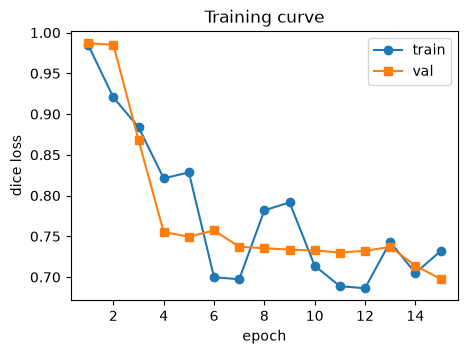

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.5))
epochs_axis = np.arange(1, train_cfg["epochs"] + 1)
ax.plot(epochs_axis, result["train_losses"], marker="o", label="train")
ax.plot(epochs_axis, result["val_losses"], marker="s", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel(f"{train_cfg['loss_name']} loss")
ax.set_title("Training curve")
ax.legend()
plt.show()

## 6. Inspect one prediction

The `"good"` filter's channel at the stream's own true `distance_modulus` --
the channel a real detection should show up most clearly in. No unwrapping
needed here: `model`'s output is already a probability in `(0, 1)`, directly
comparable to `label_stack`'s `{0, 1}` values.

**Masking matters here.** `map_stack`/`label_stack` are exactly 0.0 outside
`valid_mask` by construction (verified directly against the raw arrays, not
just documented) -- the data itself is correct. `pred`, though, is a plain
per-pixel U-Net forward pass with no explicit awareness of `valid_mask`: the
masked loss excludes invalid pixels from *training*, but nothing constrains
what the network outputs there at *inference* time, so a raw, unmasked
`imshow` of any of these arrays can visually suggest the footprint edges
"have a value" when they don't (for `map_stack`/`label_stack`) or show a
genuinely meaningless prediction (for `pred`). Every panel below is masked
(`np.where(valid_mask, image, np.nan)`, with `cmap.set_bad` rendering NaN
as light grey) so invalid pixels always read as empty -- and any other code
consuming `pred` should apply the same masking before interpreting it,
exactly as `models.losses`/`evaluation.metrics` already do internally. The
last panel is the **residual** (`true - predicted`, same masking, a
diverging colormap centered on 0, fixed to the `[-1, 1]` range this bounded
target actually spans) -- pixels where the model is confidently wrong stand
out at either extreme.

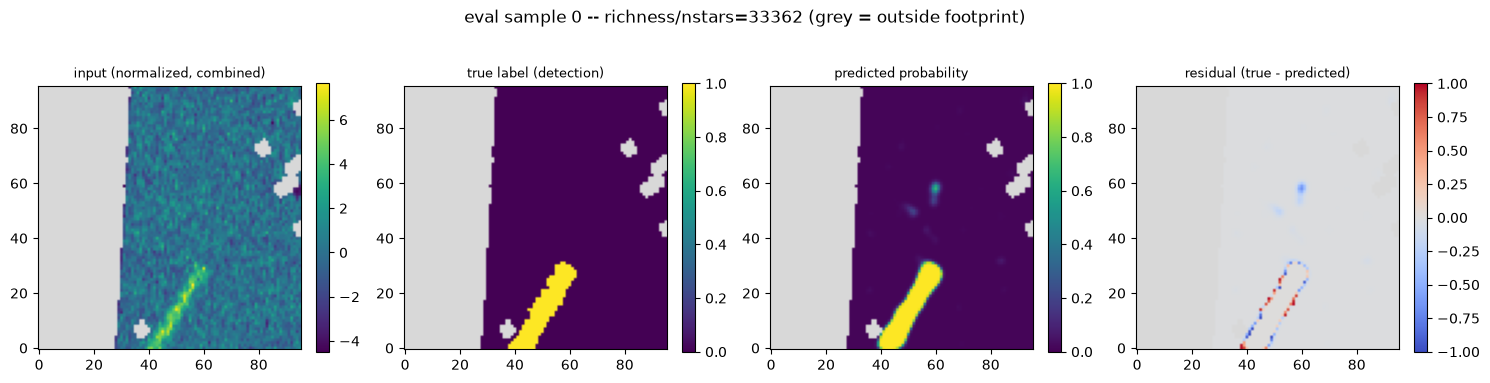

In [11]:
sample0 = eval_dataset_norm[0]
channels_meta = sample0["metadata"]["channels"]
good_idx = next(
    i
    for i, ch in enumerate(channels_meta)
    if ch["filter"] == "good" and ch["distance_modulus"] == stream_param_cfg["distance_modulus"]
)
valid_mask0 = sample0["valid_mask"]

model.eval()
with torch.no_grad():
    x = torch.from_numpy(sample0["map_stack"]).unsqueeze(0)
    pred0 = model(x)[0].numpy()
residual0 = sample0["label_stack"] - pred0

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="0.85")
resid_cmap = plt.get_cmap("coolwarm").copy()
resid_cmap.set_bad(color="0.85")


def _masked(img):
    return np.where(valid_mask0, img, np.nan)


fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, img, title, cm, kwargs in zip(
    axes,
    [
        sample0["map_stack"][good_idx],
        sample0["label_stack"][good_idx],
        pred0[good_idx],
        residual0[good_idx],
    ],
    [
        "input (normalized, combined)",
        "true label (detection)",
        "predicted probability",
        "residual (true - predicted)",
    ],
    [cmap, cmap, cmap, resid_cmap],
    [{}, dict(vmin=0, vmax=1), dict(vmin=0, vmax=1), dict(vmin=-1, vmax=1)],
):
    im = ax.imshow(_masked(img), origin="lower", cmap=cm, **kwargs)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"eval sample 0 -- richness/nstars={sample0['params']['nstars']} (grey = outside footprint)")
plt.tight_layout()
plt.show()

## 7. Evaluate on the grid, compare to the k·σ baseline

`evaluate_on_grid` walks every point of `eval_dataset_norm` (one per
richness value -- just one, here, see §1) and computes each requested
metric per sample, thresholding both `pred` and `label_stack` at 0.5 for
the segmentation metrics (`iou`/`dice`/`weighted_recall`) -- a natural
threshold on a `{0, 1}` label, not an arbitrary choice the way it would be
against a literal count. `baseline_threshold.build_baseline` is a trivial,
non-learned comparison (mean + k·σ on the same `"good"` channel of the
*unnormalized* combined map) -- worth comparing against, though not
necessarily worth *beating* at this specific richness: `stream_detection`'s
threshold makes a real stream's own pixels a large, locally sharp excess
over background almost by construction (a bright, well-resolved stream at
`nside=512`), which a simple threshold can already find. The network's
real advantage would show up on cases a fixed global threshold can't
handle -- fainter richness points, or telling the "good" channel from the
"decoy" one without being told which is which (the baseline is handed the
"good" channel directly here; the network sees both and has to learn the
difference itself) -- neither of which this single-point smoke-scale grid
actually tests yet.

In [12]:
results = evaluate_on_grid(
    model, eval_dataset_norm, metrics=["mse", "dice", "iou", "correlation", "weighted_recall"]
)

baseline_dice = []
for idx in results["id"]:
    raw_sample = eval_dataset[idx]  # unnormalized -- real count units
    baseline_pred = build_baseline(raw_sample["map_stack"][good_idx], raw_sample["valid_mask"], k=2.0)
    baseline_dice.append(dice(baseline_pred, raw_sample["label_stack"][good_idx], raw_sample["valid_mask"]))
results["baseline_dice"] = baseline_dice

results

,age,band_1,band_2,distance_modulus,length,morphology,nstars,width,z,id,mse,dice,iou,correlation,weighted_recall,baseline_dice
0,12.5,g,r,16.0,8.0,uniform,33362,0.2,0.0002,0,0.011711,0.810563,0.681467,0.831976,0.936340,0.638298
1,12.5,g,r,16.0,8.0,uniform,13282,0.2,0.0002,1,0.012005,0.683230,0.518868,0.741208,0.864780,0.274662
2,12.5,g,r,16.0,8.0,uniform,5288,0.2,0.0002,2,0.011648,0.284810,0.166052,0.399135,0.221675,0.117962
3,12.5,g,r,16.0,8.0,uniform,2106,0.2,0.0002,3,0.003759,0.000000,0.000000,0.010886,0.000000,0.044248


mean network dice:  0.445
mean baseline dice: 0.269


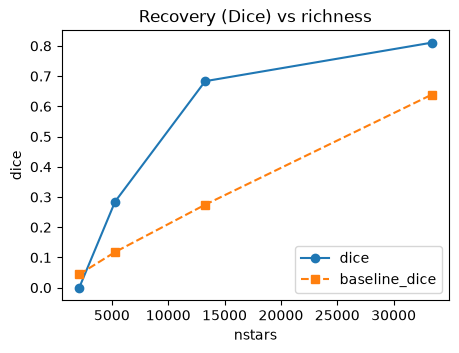

In [13]:
print(f"mean network dice:  {results['dice'].mean():.3f}")
print(f"mean baseline dice: {results['baseline_dice'].mean():.3f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
plot_recovery_vs_parameter(results, param_name="nstars", metric="dice", ax=ax, baseline_metric="baseline_dice")
ax.set_title("Recovery (Dice) vs richness")
plt.show()


## Summary

| Piece | Module |
|---|---|
| Background + matched filters + injector | `background.py`, `matched_filter.py`, `injector.py` (same as `create_data.ipynb`) |
| On-the-fly training samples + fixed eval grid | `datasets/stream_map_dataset.py` |
| Normalization + augmentation | `datasets/transforms.py` |
| Model (`head="sigmoid"`) | `models/unet.py` |
| Loss (`dice`) | `models/losses.py` |
| Training loop + checkpointing | `training/plain_runner.py` |
| Metrics, trivial baseline, per-parameter recovery curve | `evaluation/` |

This version of the notebook is the `label_policy="stream_detection"` pivot
(PLAN.md §6.12), with `count_threshold=1.0` and a real `surface_brightness`
scan (31-34, PLAN.md §6.13) rather than a single fixed point -- see §1 for
why.

**Real per-richness results from §7's actual output, not a target:**

| surface_brightness | nstars | Dice | IoU | correlation | baseline Dice |
|---|---|---|---|---|---|
| 31 | 33362 | 0.811 | 0.681 | 0.832 | 0.638 |
| 32 | 13282 | 0.683 | 0.519 | 0.741 | 0.275 |
| 33 |  5288 | 0.285 | 0.166 | 0.399 | 0.118 |
| 34 |  2106 | **0.000** | **0.000** | 0.011 | 0.044 |

**Direct answer to the question this scan was built to check: no, SB 34 is
not recovered -- not marginally, but completely (Dice and IoU both exactly
0.0).** The network's performance degrades steeply and monotonically with
richness (0.81 -> 0.68 -> 0.29 -> 0.00), consistent with `create_data.ipynb`
§4's calibration finding that SB 34's true positive-pixel count is already
thin (~27 pixels, per that sweep) before the network has to learn anything
from it at all. Worth noting in the network's defense: the trivial k·σ
baseline *also* collapses at SB 34 (0.044, essentially noise) -- this
richness point is hard in an absolute sense at this window/threshold, not
a network-specific failure, so it isn't yet possible to tell from this run
alone whether more training would let the network beat the (already near-
zero) baseline there, or whether SB 34 is out of reach at this
configuration entirely.

Plausible, not-yet-tested explanations for the gap: (1) **training budget
per richness point dropped 4x** -- the same 300-sample budget that
previously trained a single fixed richness now spreads across 4 discrete
values, so each gets a quarter as many gradient updates on average, worst
for the point needing the most (rarest positive pixels); (2) the
data-informed bias-init (§3.2) is computed by pooling across `fit_samples`
drawn from all four richness values at once, so it's calibrated to an
*average* class prior rather than each richness's actual (very different)
base rate -- plausibly a worse starting point for SB 34 specifically than
a richness-matched init would be; (3) SB 34 may simply need more
steps/capacity than this smoke-scale budget provides, independent of (1)
and (2). Distinguishing between these -- and deciding whether SB 34 is a
reasonable near-term target at all, or whether the working richness range
should stay narrower (e.g. 31-33) until Stage 1 has more training budget --
is the natural next step, not resolved by this run. Also unresolved:
`count_threshold=1.0`'s bright-end decoy contamination (PLAN.md §6.13)
isn't measured directly here (SB 30 was deliberately excluded from this
scan) -- a real gap if decoy-rejection specifically needs checking next.
